# 06 — Head-of-Household Education Imputation and AMAI Household Scores

This notebook constructs household-level variables required for the socioeconomic level calculation based on the AMAI methodology.

The process starts from the complete Origin-Destination (OD) survey, combining inhabitant- and dwelling-level information through `folio_vivienda`. Because the AMAI education component depends on the education level of the head of household, the first part of the notebook identifies at least one head-of-household record for each dwelling and maps the available OD education categories to their corresponding AMAI categories and scores.

For head-of-household records with missing education, a probabilistic multiclass model is estimated using observations with known education. Instead of assigning a single education category to each missing case, the model retains the complete probability distribution across education categories. These probabilities are then used to calculate the expected AMAI education score.

The resulting variables are propagated from the inhabitant-level OD dataset to the dwelling-level dataset. Finally, the AMAI scores associated with Internet access and the number of cars or trucks are added.

The main outputs of this notebook are:

- `od_population.csv`: complete inhabitant-level OD dataset with the education model outputs.
- `head_household_education_level_data.csv`: reduced dataset containing the variables used by the education model.
- `housing_data.csv`: dwelling-level dataset containing the AMAI-related variables generated in this notebook.
- `head_household_education_model.joblib`: fitted education model and the information required to reproduce its predictions.

The AMAI category definitions and scores used in this notebook are obtained from the 2022 AMAI questionnaire:
https://www.amai.org/descargas/CUESTIONARIO_AMAI_2022.pdf

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import eodgdl # We import this so we can have the complete OD survey data, not only the workers one

In [3]:
tables = eodgdl.load_eod(verbose=True)
# This merge replicates all household information for everyone in the house
od_population = tables.hab.reset_index().merge(tables.viv.reset_index(), on="folio_vivienda", how="left", validate="many_to_one")

DF shapes viv/hab/viaj/legs (17901, 17) (58061, 54) (154662, 23) (170509, 3)


## 1. Head-of-household identification and education score

The AMAI education component requires the education level of the head of household. However, some dwellings in the OD survey do not contain any inhabitant explicitly classified as `Jefe del hogar` in the `parentesco` variable.

To ensure that every `folio_vivienda` has at least one head-of-household record, we define an assignment rule. For a dwelling $h$ without a reported head, the oldest inhabitant is selected:

$$i_h^* = \arg\max_{i \in h} \text{age}_i.$$

The selected inhabitant is assigned as the head of household for the purposes of this analysis. We preserve a separate variable indicating whether the assignment was observed in the survey or generated using this rule.

This procedure does not modify households that already contain at least one reported head.

In [4]:
od_population["jefe_hogar_asignacion_artificial"] = od_population["parentesco"].copy()

# Identify households that already have at least one reported head
has_head = od_population.groupby("folio_vivienda")["parentesco"].transform(lambda x: (x == "Jefe del hogar").any())

# Select the oldest person only among households without a reported head
oldest_without_head_idx = od_population.loc[~has_head].groupby("folio_vivienda")["edad"].idxmax()

# Artificially assign the oldest person as head of household
od_population.loc[oldest_without_head_idx, "jefe_hogar_asignacion_artificial"] = "Jefe del hogar"

# For trazability, we need to remember if the head of household was defined artificially
od_population["jefe_hogar_fuente"] = pd.NA

od_population.loc[od_population["parentesco"] == "Jefe del hogar", "jefe_hogar_fuente"] = "observado"
od_population.loc[oldest_without_head_idx, "jefe_hogar_fuente"] = "artificial_mayor_edad"

### 1.1 Mapping education to the AMAI classification

Once the head-of-household records have been identified, the OD education categories are mapped to the categories required by the AMAI scoring system.

Let $Y_h$ be the AMAI education category from the head of dwelling $h$, and $s_k$ the AMAI score assigned to education category $k$. For an observed education category,

$$S_h = s(Y_h).$$

The OD survey does not distinguish every intermediate AMAI education category. Therefore, only AMAI categories that can be identified from the available OD responses are used in the mapping.

In [5]:
head_household_data = od_population.loc[od_population["jefe_hogar_asignacion_artificial"]=="Jefe del hogar"].copy()

# We map the attributes included in the OD survey against what is required by AMAI
education_mapping = {
    "Ninguno": "No estudió",
    "Preescolar": "No estudió",
    "Kinder": "No estudió",
    "Primaria": "Primaria Completa",
    "Secundaria": "Secundaria Completa",
    "Preparatoria o bachillerato": "Preparatoria Completa",
    "Carrera técnica con secundaria terminada": "Carrera técnica",
    "Carrera técnica con preparatoria terminada": "Carrera técnica",
    "Normal básica": "Carrera técnica",
    "Licenciatura o profesional": "Licenciatura Completa",
    "Maestría o doctorado": "Posgrado",
    "No sabe": pd.NA
}

head_household_data["ultimo_estudio_jefe_hogar"] = head_household_data["escolaridad"].map(education_mapping)

# We assign the score to the last grade. This mapping is included in the AMAI.
education_score_mapping = {
    "No estudió": 0,
    "Primaria Incompleta": 6,
    "Primaria Completa": 11,
    "Secundaria Incompleta": 12,
    "Secundaria Completa": 18,
    "Carrera comercial": 23,
    "Carrera técnica": 23,
    "Preparatoria Incompleta": 23,
    "Preparatoria Completa": 27,
    "Licenciatura Incompleta": 36,
    "Licenciatura Completa": 59,
    "Posgrado": 85
}

head_household_data["puntos_ultimo_estudio_jefe_hogar"] = head_household_data["ultimo_estudio_jefe_hogar"].map(education_score_mapping).astype("Int64")

In [6]:
head_household_data["ultimo_estudio_jefe_hogar"].value_counts(dropna=False)

ultimo_estudio_jefe_hogar
Licenciatura Completa    4721
NaN                      4107
Secundaria Completa      3343
Preparatoria Completa    3049
Primaria Completa        2099
Carrera técnica           985
Posgrado                  651
No estudió                410
Name: count, dtype: int64

The education category cannot be directly obtained for every head-of-household record. After applying the previous mapping, 4,107 observations remain without an identified education category, corresponding to approximately 21% of the head-of-household records.

Rather than removing these observations or assigning them to a single category using a deterministic rule, we estimate their education level probabilistically using the records for which education is observed.

### 1.2 Probabilistic imputation of head-of-household education

#### Predictor screening

The head-of-household records are divided into two groups:


$$\mathcal{D}_{\mathrm{known}} = \{h:Y_h\text{ is observed}\},$$

and

$$\mathcal{D}_{\mathrm{unknown}} = \{h:Y_h\text{ is missing}\}.$$

Only $\mathcal{D}_{\mathrm{known}}$ can be used to estimate and evaluate the education model. The fitted model will later be applied to $\mathcal{D}_{\mathrm{unknown}}$.

Before defining the candidate feature sets, we examine the association between the available variables and education.

For numerical predictors, association is measured using Spearman's rank correlation between each predictor $X_j$ and the observed AMAI education score $S$:

$$\rho_s(X_j,S) = \text{corr} \left(\text{rank}(X_j), \text{rank}(S) \right).$$

For categorical predictors, we use the bias-corrected Cramér's $V$, which measures association between two categorical variables and ranges approximately from 0, indicating little association, to 1, indicating stronger association.

These measures are used as screening tools only.

In [7]:
# Data for training and testing
known_education = head_household_data.loc[head_household_data["ultimo_estudio_jefe_hogar"].notna()].copy()

# Data for imputation
unknown_education = head_household_data.loc[head_household_data["ultimo_estudio_jefe_hogar"].isna()].copy()

# Data that can't be used as predictor (because they don't give information or can bias the model)
excluded_columns = [
    "escolaridad",
    "ultimo_estudio_jefe_hogar",
    "puntos_ultimo_estudio_jefe_hogar",
    "folio_vivienda",
    "folio_habitante",
    "parentesco",
    "jefe_hogar_asignacion_artificial",
    "jefe_hogar_fuente"
]

########################################
# CORRELATION TO DEFINE MODEL PREDICTORS
########################################

# Correlation for numerical values: Spearman correlation
numeric_columns = known_education.select_dtypes(include="number").columns.difference(excluded_columns)
education_numerical_correlations = known_education[list(numeric_columns) + ["puntos_ultimo_estudio_jefe_hogar"]].corr(method="spearman")["puntos_ultimo_estudio_jefe_hogar"].drop("puntos_ultimo_estudio_jefe_hogar").sort_values(key=abs, ascending=False)

# Correlation for categorial values: Cramer's V for nominal values
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)

    if table.empty:
        return np.nan

    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    r, k = table.shape

    phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(k_corrected - 1, r_corrected - 1)

    return np.sqrt(phi2_corrected / denominator) if denominator > 0 else np.nan

categorical_columns = known_education.select_dtypes(include=["object", "string", "category"]).columns.difference(excluded_columns)
education_categorial_correlation = pd.Series({column: cramers_v(known_education[column], known_education["ultimo_estudio_jefe_hogar"]) for column in categorical_columns}).sort_values(ascending=False)

In [8]:
education_numerical_correlations

edad              -0.205456
viajes_contados    0.183003
ponderador_x      -0.013765
ponderador_y      -0.008932
Name: puntos_ultimo_estudio_jefe_hogar, dtype: float64

In [9]:
education_categorial_correlation

weekend_mode_auto_particular       0.492623
ageb                               0.311601
weekend_mode_camion_autobus        0.265767
dispuesto_participar_futuro        0.247607
weekend_mode_a_pie                 0.230721
                                     ...   
weekend_dest_religion              0.005514
weekend_dest_regresar_casa         0.004284
weekend_mode_escolar_particular    0.000000
quien_apoya_viajes                 0.000000
weekend_mode_transp_informal       0.000000
Length: 63, dtype: float64

The association measures provide an initial indication of which variables may contain information about education, but they are not used as the only feature-selection criterion.

Among the numerical variables, `edad` is retained. `viajes_contados` is not included because the objective is to prioritize demographic and household characteristics rather than realized travel behavior. The survey weights are excluded because they describe the sampling design rather than the underlying education process.

For the categorical variables, we define progressively larger feature sets. The first contains demographic and household characteristics, the second adds selected mobility variables, and the third incorporates spatial information.

This structure will help us to evaluate whether the additional mobility and spatial variables improve out-of-sample probabilistic predictions.

In [10]:
education_base_features = [
    "edad",
    "sexo_nacimiento",
    "estado_civil",
    "personas_en_vivienda",
    "tenencia_vivienda",
    "ingreso_mensual_hogar",
    "n_autos_camionetas",
    "tiene_internet"
]

education_extended_features = education_base_features + [
    "weekend_mode_auto_particular",
    "weekend_mode_camion_autobus",
    "weekend_mode_a_pie",
    "salio_casa_ayer",
    "weekend_dest_visitar",
    "weekend_dest_compras_bienes_servicios"
]

education_spatial_features = education_extended_features + [
    "centralidad",
    "ageb"
]

Before fitting the models, we examine missing values in the candidate predictors.

The comparison is performed both within the known-education sample used for model estimation and within the unknown-education sample where the final model will be applied.

The preprocessing pipeline will handle the remaining missing values using median imputation for numerical predictors and the most frequent category for categorical predictors.

In [11]:
feature_sets = {
    "Base": education_base_features,
    "Extended": education_extended_features,
    "Spatial": education_spatial_features
}

for name, features in feature_sets.items():
    print(f"\n{name}")
    print(known_education[features].isna().mean().mul(100).sort_values(ascending=False))


Base
estado_civil             0.412898
edad                     0.000000
sexo_nacimiento          0.000000
personas_en_vivienda     0.000000
tenencia_vivienda        0.000000
ingreso_mensual_hogar    0.000000
n_autos_camionetas       0.000000
tiene_internet           0.000000
dtype: float64

Extended
estado_civil                             0.412898
weekend_mode_auto_particular             0.058985
weekend_mode_camion_autobus              0.058985
weekend_mode_a_pie                       0.058985
weekend_dest_visitar                     0.058985
weekend_dest_compras_bienes_servicios    0.058985
edad                                     0.000000
sexo_nacimiento                          0.000000
personas_en_vivienda                     0.000000
tenencia_vivienda                        0.000000
ingreso_mensual_hogar                    0.000000
n_autos_camionetas                       0.000000
tiene_internet                           0.000000
salio_casa_ayer                          0.0000

In [12]:
for feature in education_spatial_features:
    known_missing = known_education[feature].isna().mean() * 100
    unknown_missing = unknown_education[feature].isna().mean() * 100
    print(f"{feature}: known={known_missing:.2f}%, unknown={unknown_missing:.2f}%")

edad: known=0.00%, unknown=0.00%
sexo_nacimiento: known=0.00%, unknown=0.00%
estado_civil: known=0.41%, unknown=0.80%
personas_en_vivienda: known=0.00%, unknown=0.00%
tenencia_vivienda: known=0.00%, unknown=0.00%
ingreso_mensual_hogar: known=0.00%, unknown=0.00%
n_autos_camionetas: known=0.00%, unknown=0.00%
tiene_internet: known=0.00%, unknown=0.00%
weekend_mode_auto_particular: known=0.06%, unknown=0.02%
weekend_mode_camion_autobus: known=0.06%, unknown=0.02%
weekend_mode_a_pie: known=0.06%, unknown=0.02%
salio_casa_ayer: known=0.00%, unknown=0.00%
weekend_dest_visitar: known=0.06%, unknown=0.02%
weekend_dest_compras_bienes_servicios: known=0.06%, unknown=0.02%
centralidad: known=0.00%, unknown=0.00%
ageb: known=0.00%, unknown=0.00%


#### Training and test split

The known-education sample is divided into training and test sets before model selection.

Because multiple inhabitants can belong to the same `folio_vivienda`, the split is performed at the dwelling level. No dwelling is therefore allowed to contribute observations to both the training and test samples.

At the same time, we approximately preserve the distribution of the education target through stratification. Using five grouped folds and reserving one fold for testing gives an approximately 80/20 split:


$$\mathcal{D}_{\mathrm{known}} = \mathcal{D}_{\mathrm{train}} \cup \mathcal{D}_{\mathrm{test}}, \qquad \mathcal{D}_{\mathrm{train}} \cap \mathcal{D}_{\mathrm{test}} = \varnothing.$$

The test sample is kept separate from model selection and hyperparameter tuning and is used only for the final evaluation.

In [13]:
from sklearn.model_selection import StratifiedGroupKFold

target_column = "ultimo_estudio_jefe_hogar"
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(splitter.split(known_education, known_education[target_column], groups=known_education["folio_vivienda"]))

education_train = known_education.iloc[train_idx].copy()
education_test = known_education.iloc[test_idx].copy()

In [14]:
print(f"Training observations: {len(education_train):,}")
print(f"Testing observations: {len(education_test):,}")
print(f"Household overlap: {len(set(education_train['folio_vivienda']) & set(education_test['folio_vivienda']))}")
print()

original_distribution = known_education[target_column].value_counts(normalize=True).rename("original")
train_distribution = education_train[target_column].value_counts(normalize=True).rename("train")
test_distribution = education_test[target_column].value_counts(normalize=True).rename("test")

split_distribution = pd.concat([original_distribution, train_distribution, test_distribution], axis=1).mul(100).round(2)
split_distribution

Training observations: 12,206
Testing observations: 3,052
Household overlap: 0



,original,train,test
ultimo_estudio_jefe_hogar,,,
Licenciatura Completa,30.94,30.94,30.93
Secundaria Completa,21.91,21.91,21.92
Preparatoria Completa,19.98,19.99,19.95
Primaria Completa,13.76,13.76,13.76
Carrera técnica,6.46,6.46,6.45
Posgrado,4.27,4.26,4.29
No estudió,2.69,2.69,2.69


The resulting split contains 12,206 training observations and 3,052 testing observations, with zero overlap in `folio_vivienda`.

The education shares are also nearly identical across the complete known sample, training sample, and test sample. The split therefore satisfies both requirements: separation between dwellings and preservation of the target distribution.

#### Survey weights

The OD survey contains sampling weights that indicate how many individuals in the population are represented by each survey observation. These weights are incorporated into model fitting and evaluation so that observations contribute according to their population representation.

In [15]:
print((head_household_data["ponderador_x"] == head_household_data["ponderador_y"]).mean())
weight_column = "ponderador_x"

0.9809450038729667


The two weight columns generated by the previous merge are exactly equal for approximately 98.1% of the head-of-household records. We use `ponderador_x` consistently as the survey-weight variable for the education model.

From this point onward, the weight associated with observation $i$ is defined as $w_i$.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### 1.3 Model benchmark

Before tuning hyperparameters, we compare three classification algorithms using simple initial configurations:

- **Logistic Regression**, as a linear probabilistic baseline.
- **Random Forest**, for nonlinear relationships and interactions through an ensemble of decision trees.
- **Gradient Boosting**, for nonlinear relationships through sequentially fitted decision trees.

Each algorithm is evaluated with the Base, Extended, and Spatial feature sets. The purpose of this stage is to select a model–feature-set combination before performing a more focused hyperparameter search, ensuring compuation efficiency.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=42)
}

def build_education_pipeline(model_name, model, features):
    numeric_features = ["edad"]
    categorical_features = [feature for feature in features if feature not in numeric_features]

    numeric_transformer = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    categorical_transformer = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=model_name != "Gradient Boosting"))])
    preprocessor = ColumnTransformer([("numeric", numeric_transformer, numeric_features), ("categorical", categorical_transformer, categorical_features)])

    return Pipeline([("preprocessor", preprocessor), ("model", model)])

Model selection considers five-fold stratified grouped cross-validation within the training sample only.

For each validation fold, the model produces a probability

$$\hat p_{ik} = P(Y_i=k\mid X_i)$$

for each education category $k$.

The primary evaluation metric is the weighted multiclass log loss 

$$\mathcal{L} = - \frac{1}{\sum_i w_i} \sum_i w_i \sum_{k=1}^{K} \mathbf{1}(Y_i=k) \log(\hat p_{ik}),$$

where $K$ is the number of education categories. Lower values indicate that the model assigns more probability to the categories that are actually observed and penalizes confident incorrect predictions.

Weighted accuracy is also reported:

$$A = \frac{\sum_i w_i\mathbf{1}(\hat Y_i=Y_i)}{\sum_i w_i},$$

but it is treated as a secondary metric because the final objective is to retain the complete probability distribution instead of the most probable education category.

In [18]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
benchmark_results = []
for feature_set_name, features in feature_sets.items():
    X = education_train[features]
    y = education_train[target_column]
    groups = education_train["folio_vivienda"]
    weights = education_train[weight_column]

    for model_name, model in models.items():
        fold_log_losses = []
        fold_accuracies = []

        for train_fold_idx, val_fold_idx in cv.split(X, y, groups):
            X_train_fold = X.iloc[train_fold_idx]
            X_val_fold = X.iloc[val_fold_idx]
            y_train_fold = y.iloc[train_fold_idx]
            y_val_fold = y.iloc[val_fold_idx]
            w_train_fold = weights.iloc[train_fold_idx]
            w_val_fold = weights.iloc[val_fold_idx]

            pipeline = build_education_pipeline(model_name, model, features)
            pipeline.fit(X_train_fold, y_train_fold, model__sample_weight=w_train_fold)

            val_probabilities = pipeline.predict_proba(X_val_fold)
            val_predictions = pipeline.predict(X_val_fold)
            classes = pipeline.named_steps["model"].classes_

            fold_log_losses.append(log_loss(y_val_fold, val_probabilities, labels=classes, sample_weight=w_val_fold))
            fold_accuracies.append(accuracy_score(y_val_fold, val_predictions, sample_weight=w_val_fold))

        benchmark_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "log_loss_mean": np.mean(fold_log_losses),
            "log_loss_std": np.std(fold_log_losses),
            "accuracy_mean": np.mean(fold_accuracies),
            "accuracy_std": np.std(fold_accuracies)
        })

benchmark_results = pd.DataFrame(benchmark_results).sort_values(["log_loss_mean", "accuracy_mean"], ascending=[True, False]).reset_index(drop=True)
benchmark_results

,feature_set,model,log_loss_mean,log_loss_std,accuracy_mean,accuracy_std
0,Spatial,Gradient Boosting,1.403759,0.018024,0.455030,0.011519
1,Extended,Gradient Boosting,1.409333,0.025769,0.442611,0.019670
2,Extended,Random Forest,1.409364,0.020841,0.441307,0.016944
3,Extended,Logistic Regression,1.424445,0.023414,0.441827,0.012499
4,Base,Logistic Regression,1.461693,0.025915,0.425915,0.015506
5,Base,Gradient Boosting,1.461718,0.024741,0.430914,0.015360
6,Base,Random Forest,1.467608,0.017330,0.430234,0.010503
7,Spatial,Random Forest,1.471174,0.015464,0.429092,0.013727
8,Spatial,Logistic Regression,1.937600,0.017315,0.443215,0.007200


In [19]:
best_result = benchmark_results.iloc[0]

best_feature_set_name = best_result["feature_set"]
best_model_name = best_result["model"]
best_features = feature_sets[best_feature_set_name]

print(f"Best feature set: {best_feature_set_name}")
print(f"Best model: {best_model_name}")
print(f"CV weighted log loss: {best_result['log_loss_mean']:.4f} ± {best_result['log_loss_std']:.4f}")
print(f"CV weighted accuracy: {best_result['accuracy_mean']:.4f} ± {best_result['accuracy_std']:.4f}")

Best feature set: Spatial
Best model: Gradient Boosting
CV weighted log loss: 1.4038 ± 0.0180
CV weighted accuracy: 0.4550 ± 0.0115


The benchmark selects the **Spatial feature set with Gradient Boosting**, with a weighted cross-validation log loss of approximately 1.404 and a weighted accuracy of 0.455.

This combination is selected because it produces the lowest mean weighted log loss among the candidate pipelines. We therefore keep both the selected feature set and model fixed and proceed to tune only its hyperparameters.

### 1.4 Hyperparameter tuning

The benchmark is intended to identify the most suitable model family and feature set using relatively simple configurations. We now perform a second grouped cross-validation stage to tune the selected model.

The candidate grids implemented in the code are:

- **Logistic Regression**
  - $C \in \{0.1,1,10\}$
  - 3 configurations.

- **Random Forest**
  - combinations of `n_estimators`, `min_samples_leaf`, and `max_depth`
  - 4 configurations.

- **Gradient Boosting**
  - combinations of `n_estimators`, `learning_rate`, and `max_depth`
  - 4 configurations.

Only the grid associated with the model selected in the previous benchmark is evaluated. The same five-fold stratified grouped cross-validation procedure and survey-weighted metrics are used.

Hyperparameters are ranked first by minimum weighted log loss and then by maximum weighted accuracy in case additional discrimination is required.

In [26]:
parameter_grids = {
    "Logistic Regression": [
        {"C": 0.1},
        {"C": 1.0},
        {"C": 10.0}
    ],
    "Random Forest": [
        {"n_estimators": 300, "min_samples_leaf": 2, "max_depth": None},
        {"n_estimators": 300, "min_samples_leaf": 5, "max_depth": None},
        {"n_estimators": 500, "min_samples_leaf": 5, "max_depth": 20},
        {"n_estimators": 500, "min_samples_leaf": 10, "max_depth": 20}
    ],
    "Gradient Boosting": [
        {"n_estimators": 100, "learning_rate": 0.05, "max_depth": 2},
        {"n_estimators": 150, "learning_rate": 0.05, "max_depth": 3},
        {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3},
        {"n_estimators": 150, "learning_rate": 0.1, "max_depth": 2}
    ]
}

def make_model(model_name, params):
    if model_name == "Logistic Regression":
        return LogisticRegression(max_iter=2000, random_state=42, **params)

    if model_name == "Random Forest":
        return RandomForestClassifier(random_state=42, n_jobs=-1, **params)

    if model_name == "Gradient Boosting":
        return GradientBoostingClassifier(random_state=42, **params)

tuning_results = []

X = education_train[best_features]
y = education_train[target_column]
groups = education_train["folio_vivienda"]
weights = education_train[weight_column]

for params in parameter_grids[best_model_name]:
    fold_log_losses = []
    fold_accuracies = []

    for train_fold_idx, val_fold_idx in cv.split(X, y, groups):
        X_train_fold = X.iloc[train_fold_idx]
        X_val_fold = X.iloc[val_fold_idx]
        y_train_fold = y.iloc[train_fold_idx]
        y_val_fold = y.iloc[val_fold_idx]
        w_train_fold = weights.iloc[train_fold_idx]
        w_val_fold = weights.iloc[val_fold_idx]

        model = make_model(best_model_name, params)
        pipeline = build_education_pipeline(best_model_name, model, best_features)

        pipeline.fit(X_train_fold, y_train_fold, model__sample_weight=w_train_fold)

        val_probabilities = pipeline.predict_proba(X_val_fold)
        val_predictions = pipeline.predict(X_val_fold)
        classes = pipeline.named_steps["model"].classes_

        fold_log_losses.append(log_loss(y_val_fold, val_probabilities, labels=classes, sample_weight=w_val_fold))
        fold_accuracies.append(accuracy_score(y_val_fold, val_predictions, sample_weight=w_val_fold))

    tuning_results.append({
        "params": params,
        "log_loss_mean": np.mean(fold_log_losses),
        "log_loss_std": np.std(fold_log_losses),
        "accuracy_mean": np.mean(fold_accuracies),
        "accuracy_std": np.std(fold_accuracies)
    })

tuning_results = pd.DataFrame(tuning_results).sort_values(["log_loss_mean", "accuracy_mean"], ascending=[True, False]).reset_index(drop=True)

tuning_results

,params,log_loss_mean,log_loss_std,accuracy_mean,accuracy_std
0,"{'n_estimators': 200, 'learning_rate': 0.05, '...",1.400181,0.017134,0.457399,0.007667
1,"{'n_estimators': 150, 'learning_rate': 0.05, '...",1.403759,0.018024,0.455030,0.011519
2,"{'n_estimators': 150, 'learning_rate': 0.1, 'm...",1.407054,0.016760,0.455274,0.009221
3,"{'n_estimators': 100, 'learning_rate': 0.05, '...",1.429953,0.019829,0.447052,0.014795


In [27]:
best_params = tuning_results.iloc[0]["params"]

print("Best parameters:", best_params)
print(f"CV weighted log loss: {tuning_results.iloc[0]['log_loss_mean']:.4f}")
print(f"CV weighted accuracy: {tuning_results.iloc[0]['accuracy_mean']:.4f}")

Best parameters: {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3}
CV weighted log loss: 1.4002
CV weighted accuracy: 0.4574


The selected Gradient Boosting configuration uses 200 estimators, a learning rate of 0.05, and a maximum tree depth of 3. Its mean cross-validation log loss is approximately 1.400.

Having completed all model selection using only the training sample, we now evaluate this configuration once on the test sample that was reserved before the benchmark and tuning stages.

In [28]:
best_model = make_model(best_model_name, best_params)
best_pipeline = build_education_pipeline(best_model_name, best_model, best_features)

best_pipeline.fit(education_train[best_features], education_train[target_column], model__sample_weight=education_train[weight_column])

test_probabilities = best_pipeline.predict_proba(education_test[best_features])
test_predictions = best_pipeline.predict(education_test[best_features])
classes = best_pipeline.named_steps["model"].classes_

test_log_loss = log_loss(education_test[target_column], test_probabilities, labels=classes, sample_weight=education_test[weight_column])
test_accuracy = accuracy_score(education_test[target_column], test_predictions, sample_weight=education_test[weight_column])

print(f"Test weighted log loss: {test_log_loss:.4f}")
print(f"Test weighted accuracy: {test_accuracy:.4f}")

Test weighted log loss: 1.3813
Test weighted accuracy: 0.4684


The final test evaluation produces a weighted log loss of approximately 1.381 and a weighted accuracy of 0.468.

The test results do not show a deterioration relative to the cross-validation results. We therefore refit the selected pipeline using all observations with known education before applying it to the missing-education sample.

Aggregate preservation of the observed education distribution is evaluated separately after the probabilities have been incorporated into the complete dataset.

In [29]:
final_model = make_model(best_model_name, best_params)
final_pipeline = build_education_pipeline(best_model_name, final_model, best_features)

final_pipeline.fit(known_education[best_features], known_education[target_column], model__sample_weight=known_education[weight_column])

unknown_probabilities = final_pipeline.predict_proba(unknown_education[best_features])
education_classes = final_pipeline.named_steps["model"].classes_

probability_column_mapping = {
    "No estudió": "prob_education_no_estudio",
    "Primaria Completa": "prob_education_primaria_completa",
    "Secundaria Completa": "prob_education_secundaria_completa",
    "Carrera técnica": "prob_education_carrera_tecnica",
    "Preparatoria Completa": "prob_education_preparatoria_completa",
    "Licenciatura Completa": "prob_education_licenciatura_completa",
    "Posgrado": "prob_education_posgrado"
}

for class_name, probability_column in probability_column_mapping.items():
    class_index = list(education_classes).index(class_name)
    unknown_education[probability_column] = unknown_probabilities[:, class_index]

probability_columns = list(probability_column_mapping.values())
unknown_education["education_probability_sum"] = unknown_education[probability_columns].sum(axis=1)
unknown_education["education_probability_sum"].describe()

count    4.107000e+03
mean     1.000000e+00
std      1.153455e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: education_probability_sum, dtype: float64

### 1.5 Probabilistic education score

The fitted model provides a probability for every education category:

$$p_{hk} = P(Y_h=k\mid X_h), \qquad k=1,\ldots,K.$$

For a head-of-household record with an observed education category $Y_h$, the probability vector is represented exactly as

$$p_{hk} = \mathbf{1}(Y_h=k).$$

Therefore, the observed category receives probability 1 and all remaining categories receive probability 0.

For records with missing education, $p_{hk}$ is obtained from the fitted model. In both cases,

$$\sum_{k=1}^{K}p_{hk}=1.$$

Let $s_k$ denote the AMAI score associated with education category $k$. Instead of assigning a missing observation to a single predicted category, we calculate its expected education score by

$$\widehat{S}_h = \mathbb{E}[S_h\mid X_h] = \sum_{k=1}^{K}p_{hk}s_k.$$

For observed education, this expression reduces exactly to the corresponding AMAI score. For missing education, it provides a probability-weighted score that retains the uncertainty of the model output.

In [30]:
probability_column_mapping = {
    "No estudió": "prob_education_no_estudio",
    "Primaria Completa": "prob_education_primaria_completa",
    "Secundaria Completa": "prob_education_secundaria_completa",
    "Carrera técnica": "prob_education_carrera_tecnica",
    "Preparatoria Completa": "prob_education_preparatoria_completa",
    "Licenciatura Completa": "prob_education_licenciatura_completa",
    "Posgrado": "prob_education_posgrado"
}
probability_columns = list(probability_column_mapping.values())

for probability_column in probability_columns:
    head_household_data[probability_column] = 0.0

# In cases where we do know the level of education, we enter 1 in the corresponding category
for class_name, probability_column in probability_column_mapping.items():
    head_household_data.loc[head_household_data[target_column] == class_name, probability_column] = 1.0

# For unknown cases, we replace those zeros with the predicted probabilities
head_household_data.loc[unknown_education.index, probability_columns] = unknown_education[probability_columns].to_numpy()

# We define the expected value of the AMAI education score
head_household_data["modelo_puntos_ultimo_estudio_jefe_hogar"] = sum(head_household_data[probability_column_mapping[class_name]] * education_score_mapping[class_name] for class_name in probability_column_mapping)

### 1.6 Distributional validation

Because the model probabilities will be used directly in the socioeconomic score, we also compare the aggregate education distribution implied by the model with the distribution observed among records with known education.

For education category $k$, the probability-weighted model share is

$$\widehat{\pi}_k = \frac{\sum_h w_h p_{hk}}{\sum_h w_h}.$$

For observations with known education, $p_{hk}$ is either 0 or 1; for imputed observations, it is the model probability. The resulting distribution therefore combines observed information and probabilistic estimates without assigning missing records deterministically to individual categories.

We also compare the distribution of the original observed AMAI education score with the distribution of the expected score $\widehat S_h$.

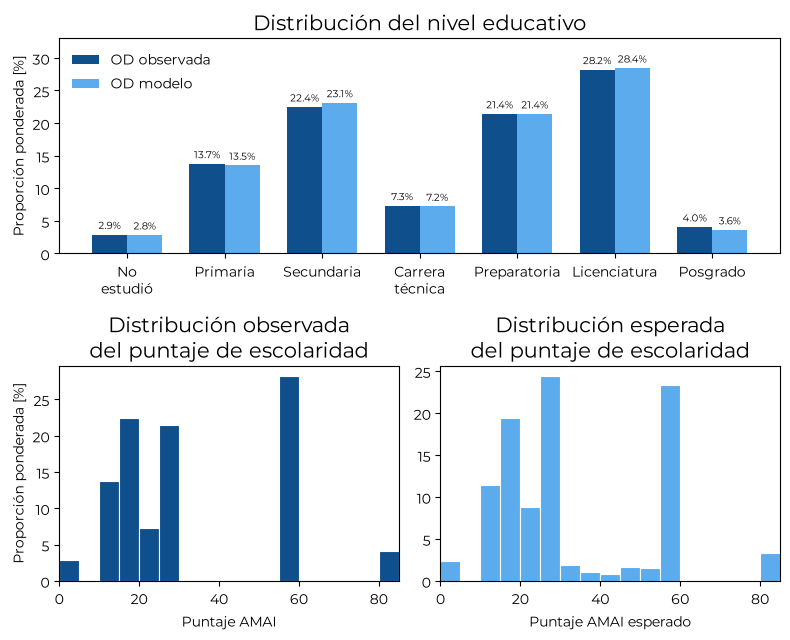

In [44]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path

########################################
# PLOT CONFIGURATION
########################################

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
output_directory = ROOT / "outputs" / "figures"
output_directory.mkdir(parents=True, exist_ok=True)

montserrat_fonts = [font for font in font_manager.findSystemFonts() if "Montserrat" in Path(font).stem]

for font in montserrat_fonts:
    font_manager.fontManager.addfont(font)

plt.rcParams["font.family"] = "Montserrat"
plt.rcParams["axes.unicode_minus"] = False

observed_color = (0.06, 0.31, 0.55)
model_color = (0.36, 0.67, 0.93)

education_order = [
    "No estudió",
    "Primaria Completa",
    "Secundaria Completa",
    "Carrera técnica",
    "Preparatoria Completa",
    "Licenciatura Completa",
    "Posgrado"
]

education_labels = [
    "No\nestudió",
    "Primaria",
    "Secundaria",
    "Carrera\ntécnica",
    "Preparatoria",
    "Licenciatura",
    "Posgrado"
]

########################################
# EDUCATION DISTRIBUTIONS
########################################

observed_education_distribution = known_education.groupby(target_column)[weight_column].sum()
observed_education_distribution = observed_education_distribution / observed_education_distribution.sum() * 100
observed_education_distribution = observed_education_distribution.reindex(education_order)
model_education_distribution = pd.Series({class_name: np.average(head_household_data[probability_column_mapping[class_name]], weights=head_household_data[weight_column]) * 100 for class_name in education_order})
education_distribution_comparison = pd.DataFrame({
    "OD observada": observed_education_distribution,
    "OD modelo": model_education_distribution
})

education_distribution_comparison

########################################
# FINAL EDUCATION MODEL FIGURE
########################################

fig = plt.figure(figsize=(8, 6.5))
gs = fig.add_gridspec(2, 2)

ax_top = fig.add_subplot(gs[0, :])
ax_bottom_left = fig.add_subplot(gs[1, 0])
ax_bottom_right = fig.add_subplot(gs[1, 1])

x = np.arange(len(education_order))
width = 0.36

# ============================================================
# 1. Observed vs model education distribution
# ============================================================

observed_values = education_distribution_comparison["OD observada"].to_numpy()
model_values = education_distribution_comparison["OD modelo"].to_numpy()

bars_observed = ax_top.bar(x - width / 2, observed_values, width, color=observed_color, label="OD observada")
bars_model = ax_top.bar(x + width / 2, model_values, width, color=model_color, label="OD modelo")

ax_top.set_title("Distribución del nivel educativo", fontsize=15)
ax_top.set_ylabel("Proporción ponderada [%]", fontsize=10)
ax_top.set_xticks(x)
ax_top.set_xticklabels(education_labels, fontsize=10)
ax_top.legend(frameon=False, fontsize=10)

for bars in [bars_observed, bars_model]:
    for bar in bars:
        height = bar.get_height()
        ax_top.text(bar.get_x() + bar.get_width() / 2, height + 0.5, f"{height:.1f}%", ha="center", va="bottom", fontsize=7)

ax_top.set_ylim(0, max(observed_values.max(), model_values.max()) * 1.16)

# ============================================================
# 3. Initial observed AMAI education score
# ============================================================

observed_score_mask = head_household_data["puntos_ultimo_estudio_jefe_hogar"].notna()
observed_scores = head_household_data.loc[observed_score_mask, "puntos_ultimo_estudio_jefe_hogar"].astype(float)
observed_weights = head_household_data.loc[observed_score_mask, weight_column].astype(float)
score_bins = np.linspace(0, 85, 18)
observed_hist_weights = observed_weights / observed_weights.sum() * 100
ax_bottom_left.hist(observed_scores, bins=score_bins, weights=observed_hist_weights, color=observed_color, edgecolor="white", linewidth=0.8)
ax_bottom_left.set_title("Distribución observada\ndel puntaje de escolaridad", fontsize=15)
ax_bottom_left.set_xlabel("Puntaje AMAI", fontsize=10)
ax_bottom_left.set_ylabel("Proporción ponderada [%]", fontsize=10)
ax_bottom_left.set_xlim(0, 85)

# ============================================================
# 4. Expected AMAI education score after the model
# ============================================================

model_scores = head_household_data["modelo_puntos_ultimo_estudio_jefe_hogar"].astype(float)
model_weights = head_household_data[weight_column].astype(float)
model_hist_weights = model_weights / model_weights.sum() * 100
ax_bottom_right.hist(model_scores, bins=score_bins, weights=model_hist_weights, color=model_color, edgecolor="white", linewidth=0.8)
ax_bottom_right.set_title("Distribución esperada\ndel puntaje de escolaridad", fontsize=15)
ax_bottom_right.set_xlabel("Puntaje AMAI esperado", fontsize=10)
ax_bottom_right.set_xlim(0, 85)

# ============================================================
# General formatting
# ============================================================

for ax in [ax_top, ax_bottom_left, ax_bottom_right]:
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(False)
    ax.set_facecolor("none")

fig.patch.set_alpha(0)

plt.tight_layout()

png_path = output_directory / "education_imputation_model_results.png"
pdf_path = output_directory / "education_imputation_model_results.pdf"

plt.savefig(png_path, dpi=600, bbox_inches="tight", transparent=True)
plt.savefig(pdf_path, bbox_inches="tight", transparent=True)

plt.show()

### 1.7 Person-level outputs

The education variables generated for the head-of-household records are returned to the complete inhabitant-level OD dataset using their original dataframe indices.

The complete OD dataset is saved for subsequent stages of the socioeconomic-level calculation. A second reduced file is also generated containing the identifiers, selected predictors, education probabilities, and AMAI education scores used in this model.

For inhabitants who are not classified as heads of household, these model-specific variables are left empty because the AMAI education component is defined from the head-of-household record.

In [32]:
output_directory = ROOT / "outputs" / "files"
output_directory.mkdir(parents=True, exist_ok=True)

#########################
# SAVE COMPLETE OD SURVEY
#########################

# Columns generated by the model
education_model_columns = ["ultimo_estudio_jefe_hogar"] + probability_columns + ["puntos_ultimo_estudio_jefe_hogar", "modelo_puntos_ultimo_estudio_jefe_hogar"]

# To make the cell rerunnable, we first delete those columns if they already exist, and then perform the join
od_population = od_population.drop(columns=education_model_columns, errors="ignore")
od_population = od_population.join(head_household_data[education_model_columns], how="left")

# Save the file
od_population.to_csv(output_directory / "od_population.csv", index=False, encoding="utf-8-sig")

#################################
# SAVE DATA INCLUDED IN THE MODEL
#################################

# Identifiers to show which row belongs to which person
identifier_columns = ["folio_vivienda", "folio_habitante", "parentesco", "jefe_hogar_asignacion_artificial", "jefe_hogar_fuente"]

education_columns = ["escolaridad", "ultimo_estudio_jefe_hogar"]
predictor_columns = best_features
score_columns = ["puntos_ultimo_estudio_jefe_hogar", "modelo_puntos_ultimo_estudio_jefe_hogar"]

# Structure of final model csv
head_household_education_level_columns = identifier_columns + predictor_columns + education_columns + probability_columns + score_columns
head_household_education_level_data = od_population[head_household_education_level_columns].copy()

# Leave all data that does not correspond to the head of household empty
non_head_mask = head_household_education_level_data["jefe_hogar_asignacion_artificial"] != "Jefe del hogar"
columns_to_mask = predictor_columns + education_columns + probability_columns + score_columns
head_household_education_level_data.loc[non_head_mask, columns_to_mask] = np.nan

# Save the file
head_household_education_level_data.to_csv(output_directory / "head_household_education_level_data.csv", index=False, encoding="utf-8-sig")

In [33]:
od_population.head(10)

,folio_vivienda,folio_habitante,fecha_x,salio_casa_ayer,razon_no_viaje,viajes_contados,dia_semana_viajes,parentesco,sexo_nacimiento,genero_identidad,...,ultimo_estudio_jefe_hogar,prob_education_no_estudio,prob_education_primaria_completa,prob_education_secundaria_completa,prob_education_carrera_tecnica,prob_education_preparatoria_completa,prob_education_licenciatura_completa,prob_education_posgrado,puntos_ultimo_estudio_jefe_hogar,modelo_puntos_ultimo_estudio_jefe_hogar
0,1,1,2023-01-25 00:00:00+00:00,Sí,NaN,7,Jueves,Jefe del hogar,Hombres,Hombres,...,Posgrado,0.0,0.0,0.0,0.0,0.0,0.0,1.0,85,85.0
1,1,2,2023-01-25 00:00:00+00:00,Sí,NaN,6,Martes,Cónyuge,Mujeres,Mujeres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
2,1,3,2023-01-25 00:00:00+00:00,Sí,NaN,4,Lunes,Hijo,Hombres,Hombres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
3,1,4,2023-01-25 00:00:00+00:00,Sí,NaN,5,Jueves,Hijo,Mujeres,Mujeres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
4,1,5,2023-01-25 00:00:00+00:00,Sí,NaN,5,Viernes,Hijo,Mujeres,Mujeres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
5,2,1,2023-01-26 00:00:00+00:00,Sí,NaN,2,Miércoles,Jefe del hogar,Hombres,Hombres,...,Primaria Completa,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11,11.0
6,2,2,2023-01-26 00:00:00+00:00,No,Otros (especifique),0,NaN,Otro parentesco,Hombres,Hombres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
7,2,3,2023-01-26 00:00:00+00:00,No,Otros (especifique),0,NaN,Compañero,Hombres,Hombres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
8,3,1,2023-01-26 00:00:00+00:00,No,Otros (especifique),0,NaN,Cónyuge,Mujeres,Mujeres,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
9,3,2,2023-01-26 00:00:00+00:00,Sí,NaN,2,Jueves,Jefe del hogar,Hombres,Hombres,...,Secundaria Completa,0.0,0.0,1.0,0.0,0.0,0.0,0.0,18,18.0


In [34]:
head_household_education_level_data.head(10)

,folio_vivienda,folio_habitante,parentesco,jefe_hogar_asignacion_artificial,jefe_hogar_fuente,edad,sexo_nacimiento,estado_civil,personas_en_vivienda,tenencia_vivienda,...,ultimo_estudio_jefe_hogar,prob_education_no_estudio,prob_education_primaria_completa,prob_education_secundaria_completa,prob_education_carrera_tecnica,prob_education_preparatoria_completa,prob_education_licenciatura_completa,prob_education_posgrado,puntos_ultimo_estudio_jefe_hogar,modelo_puntos_ultimo_estudio_jefe_hogar
0,1,1,Jefe del hogar,Jefe del hogar,observado,51.0,Hombres,Casado,5,Propia,...,Posgrado,0.0,0.0,0.0,0.0,0.0,0.0,1.0,85,85.0
1,1,2,Cónyuge,Cónyuge,<NA>,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
2,1,3,Hijo,Hijo,<NA>,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
3,1,4,Hijo,Hijo,<NA>,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
4,1,5,Hijo,Hijo,<NA>,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
5,2,1,Jefe del hogar,Jefe del hogar,observado,68.0,Hombres,Soltero,3,Rentada,...,Primaria Completa,0.0,1.0,0.0,0.0,0.0,0.0,0.0,11,11.0
6,2,2,Otro parentesco,Otro parentesco,<NA>,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
7,2,3,Compañero,Compañero,<NA>,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
8,3,1,Cónyuge,Cónyuge,<NA>,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
9,3,2,Jefe del hogar,Jefe del hogar,observado,25.0,Hombres,Casado,3,Prestada,...,Secundaria Completa,0.0,0.0,1.0,0.0,0.0,0.0,0.0,18,18.0


## 2. Propagation to the dwelling-level dataset

The socioeconomic-level calculation ultimately requires one row per dwelling rather than one row per inhabitant. Thus, we transfer the variables generated in the previous section from `od_population` to the OD dwelling table `tables.viv`.

The common key is `folio_vivienda`.

Before the merge, the head-of-household information is reduced to one record per `folio_vivienda`. The resulting table is then merged with the dwelling data using a one-to-one left join:

$$\text{housing data} \leftarrow \text{housing data} \;\mathrm{LEFT\ JOIN}\; \text{education data}.$$

The number of rows in the dwelling dataset must remain unchanged. The merge adds columns but does not add or remove dwellings.

In [35]:
od_data = pd.read_csv("/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/informal_jobs/outputs/files/od_population.csv", low_memory=False)

housing_data = tables.viv.reset_index().copy()
education_household_columns = od_data.loc[:, "ultimo_estudio_jefe_hogar":].columns.tolist()
family_summary = od_data.groupby("folio_vivienda").agg(n_personas=("folio_vivienda", "size"), n_jefes=("jefe_hogar_asignacion_artificial", lambda x: (x == "Jefe del hogar").sum()), parentescos=("parentesco", lambda x: list(x.dropna()))).reset_index()

head_data = od_data.loc[od_data["jefe_hogar_asignacion_artificial"] == "Jefe del hogar", ["folio_vivienda"] + education_household_columns].copy()
household_education = head_data.groupby("folio_vivienda", as_index=False)[education_household_columns].first()
family_data = family_summary.merge(household_education, on="folio_vivienda", how="left", validate="one_to_one")

n_housing_before = len(housing_data)

housing_data = housing_data.drop(columns=education_household_columns, errors="ignore")
housing_data = housing_data.merge(family_data[["folio_vivienda"] + education_household_columns], on="folio_vivienda", how="left", validate="one_to_one")

assert len(housing_data) == n_housing_before

print(f"Housing observations: {len(housing_data):,}")
print(f"Final columns: {housing_data.shape[1]:,}")

Housing observations: 17,901
Final columns: 28


### 2.1 Consistency check of the head-of-household assignment

Before continuing with the dwelling-level variables, we verify the coverage produced by the head-of-household assignment procedure.

For every dwelling $h$, let

$$N_h^{\mathrm{head}} = \sum_{i\in h}\mathbf{1} (\text{person }i\text{ is classified as head}).$$

The assignment procedure requires

$$N_h^{\mathrm{head}}\geq1 \qquad \forall h.$$

The following cells inspect the complete distribution of $N_h^{\mathrm{head}}$ and then verify this condition directly.

The distribution also shows that some `folio_vivienda` values contain more than one inhabitant reported as a head of household. Consequently, when the previous step reduces the data to one row per dwelling, `groupby(...).first()` retains the first available head-of-household record for those cases.

In [36]:
heads_per_household = od_data.groupby("folio_vivienda")["jefe_hogar_asignacion_artificial"].apply(lambda x: (x == "Jefe del hogar").sum())
heads_per_household.value_counts().sort_index()

jefe_hogar_asignacion_artificial
1    16475
2     1390
3       34
4        2
Name: count, dtype: int64

In [37]:
(heads_per_household >= 1).all()

np.True_

## 3. Additional AMAI household components

### 3.1 Internet access

The AMAI methodology assigns a score according to whether the dwelling has Internet access.

For dwelling $h$,

$$S_h^{\mathrm{internet}} = \begin{cases} 32, & \text{if Internet access is reported},\\ 0, & \text{otherwise}. \end{cases}$$

The OD variable `tiene_internet` can be mapped directly to the corresponding AMAI score.

In [48]:
internet_score_mapping = {
    "No": 0,
    "Sí": 32
}

housing_data["puntos_internet"] = housing_data["tiene_internet"].map(internet_score_mapping).astype("Int64")

### 3.2 Number of cars or trucks

The number of cars or trucks available in the dwelling is also mapped directly to its AMAI score.

For dwelling $h$,

$$S_h^{\mathrm{vehicles}} = \begin{cases} 0, & n_h=0,\\ 22, & n_h=1,\\ 43, & n_h\geq2, \end{cases}$$

where $n_h$ is the reported number of cars or trucks in the dwelling.

In [61]:
cars_score_mapping = {
    "0": 0,
    "1": 22,
    "2": 43,
    "3": 43,
    "4 o más": 43
}

housing_data["puntos_numero_autos_camionetas"] = housing_data["n_autos_camionetas"].map(cars_score_mapping).astype("Int64")

## 4. Final outputs

The final dwelling-level dataset is saved as `housing_data.csv`. At this point it contains the head-of-household education information generated by the probabilistic model together with the additional AMAI components calculated in this notebook.

The fitted education model is also serialized as a reusable bundle. In addition to the fitted preprocessing and classification pipeline, the saved object contains:

- the selected model name;
- the selected hyperparameters;
- the predictor variables;
- the target variable;
- the AMAI education-score mapping; and
- the mapping between education categories and probability columns.

Saving this information together with the fitted pipeline allows the education model to be reproduced and applied consistently in subsequent stages of the socioeconomic-level calculation.

In [74]:
import joblib

In [76]:
files_output_directory = ROOT / "outputs" / "files"
models_output_directory = ROOT / "outputs" / "models"

files_output_directory.mkdir(parents=True, exist_ok=True)
models_output_directory.mkdir(parents=True, exist_ok=True)

#####################
# SAVE HOUSING DATA
#####################

housing_data.to_csv(files_output_directory / "housing_data.csv", index=False, encoding="utf-8-sig")

#####################
# SAVE EDUCATION MODEL
#####################

education_model_bundle = {
    "pipeline": final_pipeline,
    "model_name": best_model_name,
    "parameters": best_params,
    "features": best_features,
    "target": target_column,
    "education_score_mapping": education_score_mapping,
    "probability_column_mapping": probability_column_mapping
}

joblib.dump(education_model_bundle, models_output_directory / "head_household_education_model.joblib")

['/Users/sebastiangutierrezbernal/Desktop/Tec/Ciudades para el futuro/Proyecto Transporte GDL/informal_jobs/outputs/models/head_household_education_model.joblib']